# Assignment 1.1: Color Model Conversion

**Topic:** RGB to HSI Color Model Conversion

## Objective

To implement the mathematical conversion of an RGB image into the HSI (Hue, Saturation, Intensity) color model using Python, NumPy, and Matplotlib, and visualize the resulting H, S, and I components.

## Learning Outcomes

- Understand the mathematical relationship between RGB and HSI color models.
- Normalize RGB image values to the range $[0,1]$.
- Calculate Hue, Saturation, and Intensity using the equations provided in the lecture.
- Handle numerical edge cases such as zero intensity and floating-point values outside the valid `arccos` range.
- Visualize the individual HSI components using Matplotlib.


## 1. Mathematical Derivation

Let the normalized RGB values be:

$$R,G,B \in [0,1]$$

### Intensity

$$
I = \frac{1}{3}(R+G+B)
$$

Intensity represents the average brightness of the pixel.

### Saturation

$$
S = 1 - \frac{3}{R+G+B}\min(R,G,B)
$$

If $R+G+B=0$, the saturation is defined as $0$ because the pixel is black and has no meaningful color information.

### Hue

First calculate:

$$
\theta = \cos^{-1}\left(
\frac{\frac{1}{2}[(R-G)+(R-B)]}
{\sqrt{(R-G)^2+(R-B)(G-B)}}
\right)
$$

where $\theta$ is expressed in degrees.

Then:

$$
H =
\begin{cases}
\theta, & B \leq G\\
360^\circ-\theta, & B>G
\end{cases}
$$

For pixels where $R=G=B$, hue is undefined. In the implementation, hue is set to $0^\circ$ for such achromatic pixels.


## 2. Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['image.cmap'] = 'gray'


## 3. Implement RGB → HSI Conversion

The function below follows the lecture equations directly. The implementation is vectorized with NumPy so that the conversion can be applied to an entire image efficiently.


In [2]:
def rgb_to_hsi(rgb_image):
    """
    Convert an RGB image to the HSI color model.

    Parameters
    ----------
    rgb_image : numpy.ndarray
        RGB image with shape (height, width, 3).
        Values may be uint8 [0, 255] or floating-point [0, 1].

    Returns
    -------
    H : numpy.ndarray
        Hue in degrees, range [0, 360].
    S : numpy.ndarray
        Saturation, range [0, 1].
    I : numpy.ndarray
        Intensity, range [0, 1].
    """

    image = np.asarray(rgb_image)

    if image.ndim != 3 or image.shape[-1] != 3:
        raise ValueError("Input must be an RGB image with shape (height, width, 3).")

    # Convert to floating point and normalize to [0, 1].
    image = image.astype(np.float64)
    if image.max() > 1.0:
        image /= 255.0

    R = image[:, :, 0]
    G = image[:, :, 1]
    B = image[:, :, 2]

    # ---------------------------------------------------------
    # Intensity: I = (R + G + B) / 3
    # ---------------------------------------------------------
    I = (R + G + B) / 3.0

    # ---------------------------------------------------------
    # Saturation: S = 1 - [3 / (R + G + B)] * min(R,G,B)
    # ---------------------------------------------------------
    rgb_sum = R + G + B
    rgb_min = np.minimum(np.minimum(R, G), B)

    S = np.zeros_like(I)
    nonzero_sum = rgb_sum > 1e-12
    S[nonzero_sum] = 1.0 - (
        3.0 * rgb_min[nonzero_sum] / rgb_sum[nonzero_sum]
    )

    # ---------------------------------------------------------
    # Hue
    # theta = acos( numerator / denominator )
    # ---------------------------------------------------------
    numerator = 0.5 * ((R - G) + (R - B))
    denominator = np.sqrt((R - G) ** 2 + (R - B) * (G - B))

    # Avoid division by zero for achromatic pixels.
    theta_ratio = np.zeros_like(I)
    valid_hue = denominator > 1e-12
    theta_ratio[valid_hue] = (
        numerator[valid_hue] / denominator[valid_hue]
    )

    # Floating-point round-off can produce values slightly outside [-1, 1].
    theta_ratio = np.clip(theta_ratio, -1.0, 1.0)

    theta = np.degrees(np.arccos(theta_ratio))

    H = np.where(B <= G, theta, 360.0 - theta)

    # Hue is conventionally set to 0 for achromatic pixels.
    H[~valid_hue] = 0.0

    # Keep numerical results inside expected ranges.
    H = np.clip(H, 0.0, 360.0)
    S = np.clip(S, 0.0, 1.0)
    I = np.clip(I, 0.0, 1.0)

    return H, S, I


## 4. Test the Formula with Individual Pixels

Before processing a complete image, test the implementation with several basic colors. This helps verify that the mathematical implementation behaves as expected.


In [3]:
test_pixels = np.array([
    [1.0, 0.0, 0.0],  # Red
    [0.0, 1.0, 0.0],  # Green
    [0.0, 0.0, 1.0],  # Blue
    [1.0, 1.0, 0.0],  # Yellow
    [0.0, 1.0, 1.0],  # Cyan
    [1.0, 0.0, 1.0],  # Magenta
    [1.0, 1.0, 1.0],  # White
    [0.0, 0.0, 0.0],  # Black
    [0.5, 0.5, 0.5],  # Gray
], dtype=np.float64)

test_image = test_pixels.reshape(-1, 1, 3)
H_test, S_test, I_test = rgb_to_hsi(test_image)

print(f"{'Color':<10} {'Hue (°)':>10} {'Saturation':>14} {'Intensity':>12}")
print('-' * 52)

names = ['Red', 'Green', 'Blue', 'Yellow', 'Cyan', 'Magenta', 'White', 'Black', 'Gray']

for name, h, s, i in zip(names, H_test[:, 0], S_test[:, 0], I_test[:, 0]):
    print(f"{name:<10} {h:>10.2f} {s:>14.4f} {i:>12.4f}")


Color         Hue (°)     Saturation    Intensity
----------------------------------------------------
Red              0.00         1.0000       0.3333
Green          120.00         1.0000       0.3333
Blue           240.00         1.0000       0.3333
Yellow          60.00         1.0000       0.6667
Cyan           180.00         1.0000       0.6667
Magenta        300.00         1.0000       0.6667
White            0.00         0.0000       1.0000
Black            0.00         0.0000       0.0000
Gray             0.00         0.0000       0.5000


### Expected Behavior

For the primary colors, the expected hue values are approximately:

| Color | Hue | Saturation | Intensity |
|---|---:|---:|---:|
| Red | $0^\circ$ | 1 | 1/3 |
| Green | $120^\circ$ | 1 | 1/3 |
| Blue | $240^\circ$ | 1 | 1/3 |
| Yellow | $60^\circ$ | 1 | 2/3 |
| Cyan | $180^\circ$ | 1 | 2/3 |
| Magenta | $300^\circ$ | 1 | 2/3 |
| White | undefined → 0° by implementation | 0 | 1 |
| Black | undefined → 0° by implementation | 0 | 0 |
| Gray | undefined → 0° by implementation | 0 | 0.5 |


## 5. Load an RGB Image

Place your own image inside `assets/input/` if required by the course. The code below first tries to load `assets/input/sample.jpg`. If the file is not available, it uses the `scikit-image` sample image so that the notebook remains directly executable.


In [4]:
from pathlib import Path

image_path = Path("../data/input/sample.jpg")

if image_path.exists():
    rgb_image = np.array(Image.open(image_path).convert("RGB"))
    image_source = str(image_path)
else:
    from skimage import data
    rgb_image = data.astronaut()
    image_source = "scikit-image sample image (astronaut)"

print("Image source:", image_source)
print("Image shape:", rgb_image.shape)
print("Data type:", rgb_image.dtype)
print("Minimum value:", rgb_image.min())
print("Maximum value:", rgb_image.max())


Image source: ..\data\input\sample.jpg
Image shape: (480, 640, 3)
Data type: uint8
Minimum value: 0
Maximum value: 255


## 6. Display the Original RGB Image

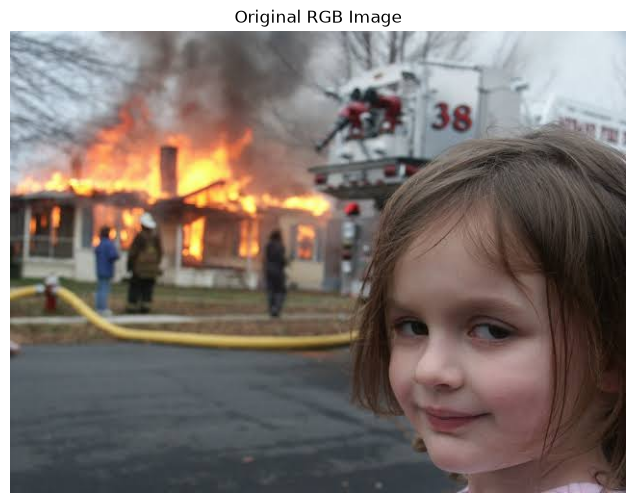

In [5]:
plt.figure(figsize=(8, 6))
plt.imshow(rgb_image)
plt.title("Original RGB Image")
plt.axis("off")
plt.show()


## 7. Convert RGB Image to HSI

In [6]:
H, S, I = rgb_to_hsi(rgb_image)

print("HSI conversion completed.")
print(f"Hue range:        {H.min():.2f}° to {H.max():.2f}°")
print(f"Saturation range: {S.min():.4f} to {S.max():.4f}")
print(f"Intensity range:  {I.min():.4f} to {I.max():.4f}")


HSI conversion completed.
Hue range:        0.00° to 359.47°
Saturation range: 0.0000 to 1.0000
Intensity range:  0.0065 to 0.9477


## 8. Visualize the HSI Components

Hue is measured in degrees from $0^\circ$ to $360^\circ$. For visualization, the hue image is normalized to $[0,1]$ and displayed using the cyclic `hsv` colormap. Saturation and intensity naturally lie in $[0,1]$ and are displayed using grayscale.

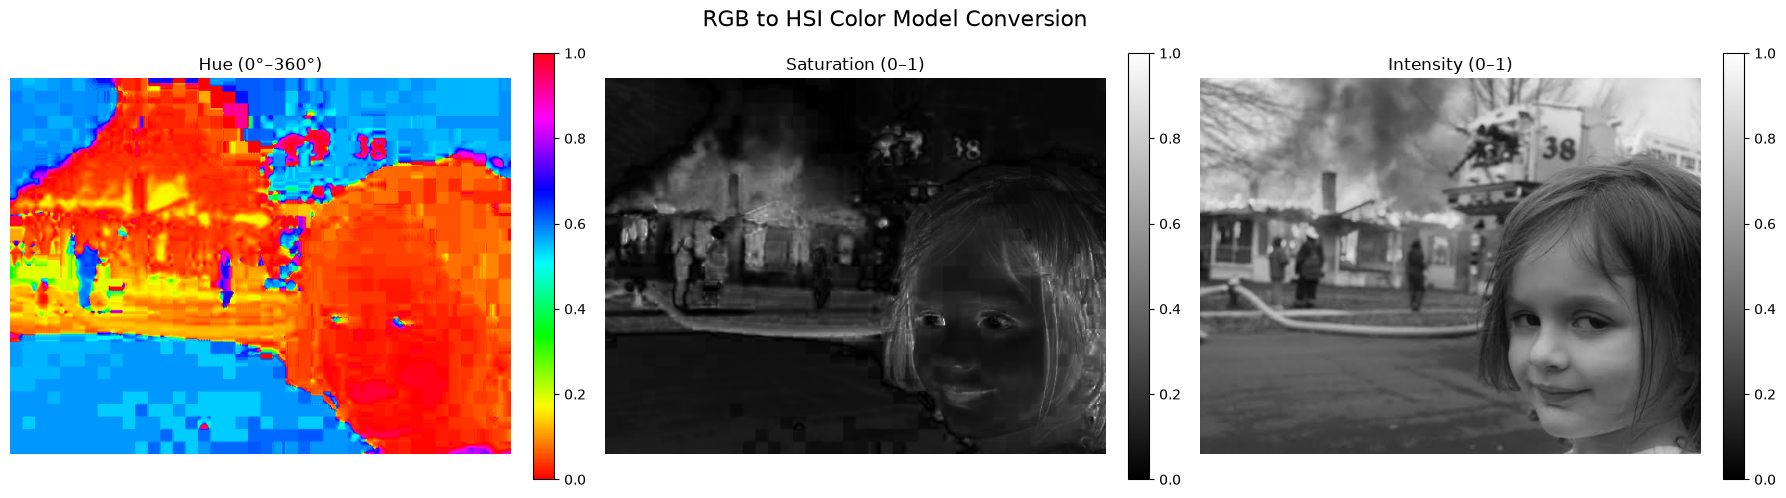

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Hue
hue_display = H / 360.0
im0 = axes[0].imshow(hue_display, cmap="hsv", vmin=0, vmax=1)
axes[0].set_title("Hue (0°–360°)")
axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Saturation
im1 = axes[1].imshow(S, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Saturation (0–1)")
axes[1].axis("off")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Intensity
im2 = axes[2].imshow(I, cmap="gray", vmin=0, vmax=1)
axes[2].set_title("Intensity (0–1)")
axes[2].axis("off")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle("RGB to HSI Color Model Conversion", fontsize=16)
plt.tight_layout()
plt.show()


## 9. Display RGB and HSI Results Together

The following figure provides a compact comparison between the original RGB image and the three calculated HSI components.

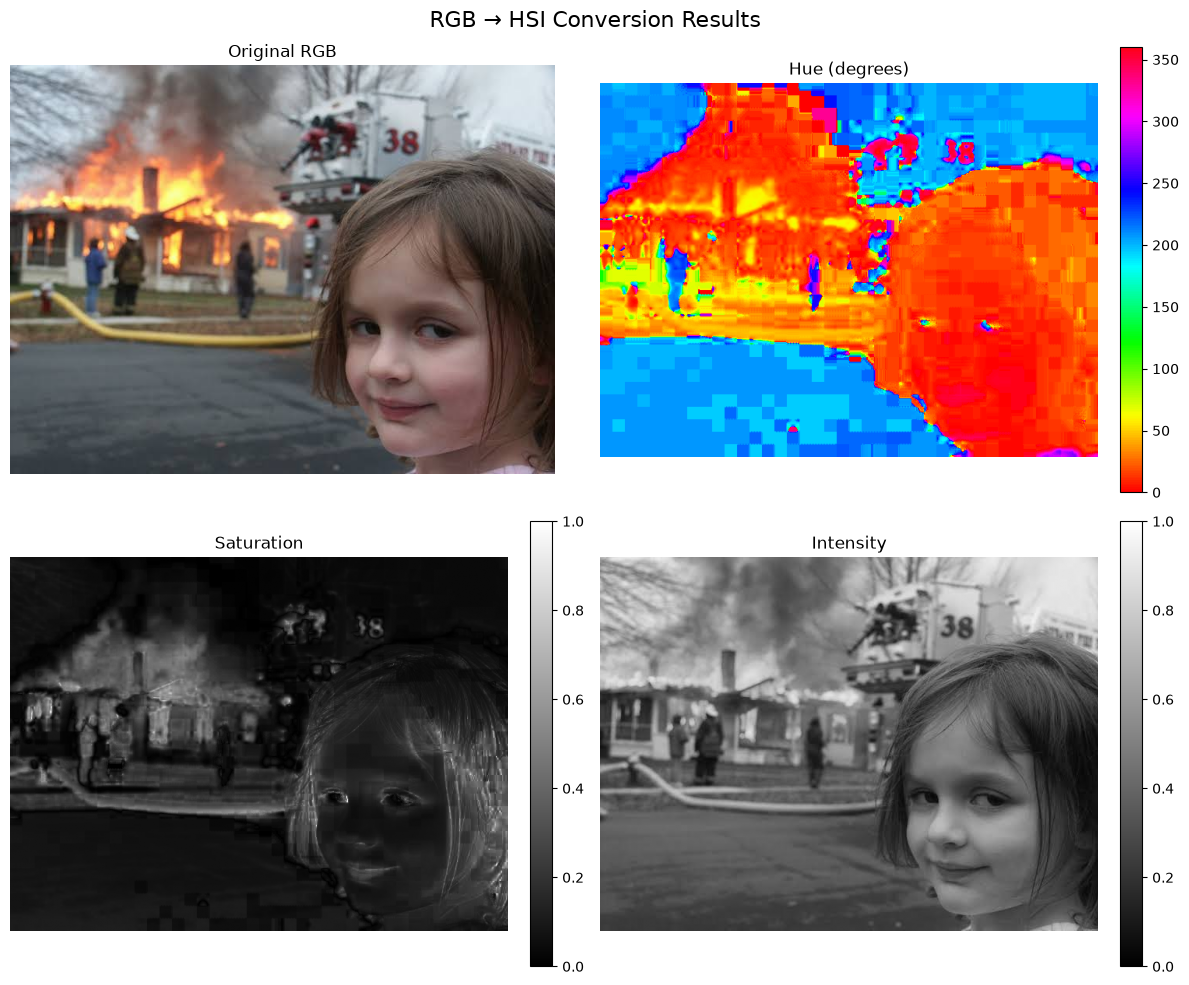

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(rgb_image)
axes[0, 0].set_title("Original RGB")
axes[0, 0].axis("off")

im_h = axes[0, 1].imshow(H, cmap="hsv", vmin=0, vmax=360)
axes[0, 1].set_title("Hue (degrees)")
axes[0, 1].axis("off")
fig.colorbar(im_h, ax=axes[0, 1], fraction=0.046, pad=0.04)

im_s = axes[1, 0].imshow(S, cmap="gray", vmin=0, vmax=1)
axes[1, 0].set_title("Saturation")
axes[1, 0].axis("off")
fig.colorbar(im_s, ax=axes[1, 0], fraction=0.046, pad=0.04)

im_i = axes[1, 1].imshow(I, cmap="gray", vmin=0, vmax=1)
axes[1, 1].set_title("Intensity")
axes[1, 1].axis("off")
fig.colorbar(im_i, ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.suptitle("RGB → HSI Conversion Results", fontsize=16)
plt.tight_layout()
plt.show()


## 10. Statistical Analysis of HSI Components

The following statistics provide numerical information about the converted image.

In [9]:
print("HSI Component Statistics")
print("=" * 40)

print("Hue")
print(f"  Minimum : {H.min():.2f}°")
print(f"  Maximum : {H.max():.2f}°")
print(f"  Mean    : {H.mean():.2f}°")

print("\nSaturation")
print(f"  Minimum : {S.min():.4f}")
print(f"  Maximum : {S.max():.4f}")
print(f"  Mean    : {S.mean():.4f}")

print("\nIntensity")
print(f"  Minimum : {I.min():.4f}")
print(f"  Maximum : {I.max():.4f}")
print(f"  Mean    : {I.mean():.4f}")


HSI Component Statistics
Hue
  Minimum : 0.00°
  Maximum : 359.47°
  Mean    : 106.83°

Saturation
  Minimum : 0.0000
  Maximum : 1.0000
  Mean    : 0.1353

Intensity
  Minimum : 0.0065
  Maximum : 0.9477
  Mean    : 0.4235


## 11. Discussion

The RGB color model represents a color using the three primary components Red, Green, and Blue. Although RGB is convenient for display devices, it does not separate color information from brightness in a way that is always convenient for image-processing operations.

The HSI color model separates the image into three components: Hue, Saturation, and Intensity. Hue represents the dominant color, saturation describes the purity of the color, and intensity represents the average brightness of the pixel.

During the conversion, RGB values are first normalized to the range $[0,1]$. Intensity is calculated as the arithmetic mean of the three normalized RGB components. Saturation is calculated from the minimum RGB component and the RGB sum. Hue is obtained from an angle calculated using the inverse cosine expression from the lecture.

Special cases are important in the implementation. For a black pixel, the RGB sum is zero, so the saturation expression would otherwise involve division by zero. Therefore, saturation is assigned a value of zero. Similarly, hue is undefined for achromatic pixels where the RGB components are equal; the implementation assigns such pixels a hue of $0^\circ$. Floating-point clipping is also used before applying `arccos()` to prevent small numerical errors from producing invalid values outside the interval $[-1,1]$.


## 12. Conclusion

The RGB image was successfully converted into the HSI color model using the mathematical equations specified in the lecture. The resulting Hue, Saturation, and Intensity components were calculated independently and visualized using Matplotlib.

The experiment demonstrates that the HSI representation separates color-related information (Hue and Saturation) from brightness-related information (Intensity), which makes it useful for several image-processing applications.
